# Multi-Class Image Classifier with Preprocessing Benchmarks, Interactive Data Cleaning & Model Serialization

## Overview
This notebook implements an end-to-end computer vision workflow for multi-class bear classification (`grizzly`, `black`, `teddy`, `polar`). It covers resilient web scraping, systematic image transform benchmarking (squishing, padding, random resized cropping, batch augmentations), fine-tuning a ResNet-18 model, diagnosing misclassifications using top losses and confusion matrices, cleaning noisy dataset entries via `ImageClassifierCleaner`, and serializing the model (`.pkl`) for production inference.

## Key Technical Components
* **Resilient Multi-Threaded Scraping:** Implements an automated DuckDuckGo image scraping pipeline with exponential backoff/retry logic (`with DDGS()`) and parallel multi-worker downloads (`download_images(..., n_workers=8)`).
* **Dataset Sanitization:** Scans and unlinks corrupt, zero-byte, or unreadable image files prior to batch construction using `verify_images`.
* **Preprocessing & Augmentation Comparative Benchmarks:** Systematically tests and visualizes distinct input processing pipelines via the `DataBlock` API:
  * `Resize(..., ResizeMethod.Squish)`: Ratio compression without cropping.
  * `Resize(..., ResizeMethod.Pad)`: Aspect-ratio preservation with zero-padding.
  * `RandomResizedCrop`: Dynamic spatial cropping across scales (`min_scale=0.3` to `0.5`).
  * `aug_transforms`: Batch-level augmentations (rotation, zoom, lighting shifts, flips).
* **Transfer Learning & Model Training:** Fine-tunes a pretrained **ResNet-18** architecture with discriminative learning rate schedules and error rate tracking.
* **Error Diagnosis & Post-Training Data Cleaning:** 
  * Computes confusion matrices and plots top validation loss samples via `ClassificationInterpretation`.
  * Integrates the interactive GUI `ImageClassifierCleaner` to prune noisy background samples and relabel ambiguous instances directly on disk.
* **Model Serialization & Production Inference:** Packages model architecture, learned weights, and vocabulary into a standalone `.pkl` file via `learn.export()`, validating standalone deployment with `load_learner` and single-instance prediction.

--------------
--------------
--------------

## This project is about a bear detector to detect three types of bear: grizzly, black, and teddy bears. (polar as well)

In [1]:
# hide
! [ -e /content ] && pip install -Uqq fastbook nbdev ## Command A && Command B logic is if A succeeds then run B
import fastbook     # import fastbook module into our python environment
fastbook.setup_book()


# * ![-e/content] is a bash command that checks if a directory named /content exists.
#       ! is used to tell that execute it as not a python command but a bash/shell command.
#       -e stands for "exists". It checks of specific file/directory exists on the system.
#       /content is used to check if you are on google colab (redundant here as /content is the google colab root folder)

# * As /content is not found [-e/content] becomes False and ![-e/content] becomes true due to ! at beginning and fastbook is installed.
# * fastbook.setup_book() doesn't do anything here but if it were a colab notebook then instead of files disapperaing at closing browser 
#   window, it automatically triggers a pop-up mount to our Google Drive(create folder /content/gdrive, setup shortcut variable gdrive, 
#   save DL models and datasets permanently). Kaggle has its own persistent storage system(the "/kaggle/working" directory).
#   #hide was used as a directive by nbdev. The fastbook is written entirely in Jupyter Notebooks, so while printing they used nbdev to 
#    convert these notebook into printed book without showing code output it in the final book(but shown on kaggle/colab)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 12.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.6/91.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.7/241.7 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.2/149.2 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.1/364.1 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.4/94.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.0/83.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This b

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [2]:
# Ignore bigframes warning/error as we aren't using the library and if we install old version of rich i.e., <14.0.0 we will get a new error
#  "fastbook requires rich>=14.0.0" and fastai/fastbook breaks

In [3]:
from fastbook import *    # imports the helper functions specifically created for the FastBook curriculum(especially for the image search tool like ddg/bing etc.)
from fastai.vision.widgets import *  # For the buttons/UI
from fastai.vision.all import * # For training the AI
from IPython.display import display

# Production

# Gathering Data

In [4]:
!pip install -Uqq ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 60.1 MB/s eta 0:00:0000:0100:01


In [5]:
import shutil

In [6]:
#search_images_ddg  # old method not working
# ims = search_images_ddg('grizzly bear')   # it downloads the URLs of .jpg/.png image links and returns a list of URLs
# len(ims)

# Use brave/bing here for better results
# duckduckgo usually looks for about 200 images, we can either increase or decrase the number of images with 
# ims = search_images_ddg('grizzly bear', max_images = 150)

In [7]:
# This is the "DATA COLLECTOR". What the code does here is scrap DuckDuckGo and fetch us a clean set of photos 
# L is fastcore (superpower) List
'''
The purpose of L list here is:
- We use L as a transformer and a container to turn a messy stream of data into a clean, actionable list.
- When we call DDGS().images, DuckDuckGo doesn't send us 200 images at once instead, it sends a generator. L(...) consumes the generator,
  iterating through the search results and pulls them into memory. ".itemgot('image')" is a functional mapping. Instead of writing a for 
  loop for extract URLs. L does it internally at high speed.
- By converting the generator to L, we do lose some memory over pure generator(this memory is small storing 200 dictionaries briefly
  and a list of URLs) but the main advantage is generator is used for temporary purpose like streaming(read data only once) not data 
  storage as it forgets, meanwhile list stores the data and we can also have 'random access' like 1st image then 5th image directly.
- But what's the need for future storage with a list?? Operations like 1. Checking the length(len(results)), 2. Filtering out broken URLs,
  3. Slicing(e.g. results[:10]) 
'''
# search_images acts here as the wrapper function to make the complete process of talking to a website look easy, single command.
import time
from ddgs import DDGS 
from fastcore.all import L

def search_images(keyword, max_images=200): 
    print(f"Searching for '{keyword}'...")
    # Context Manager here {with DDGS() as ddgs: for loop} isn't that much useful here as its work is to close the session properly even if code crashes in middle.
    # But as the code has retry loop(for i in range(3), it creates a fresh new connection) without it code can work.
    # One problem is if we search multiple image category(like 50/100 categories) then it may look a bit more 'bot' like/ spammy to 
    #  DDG servers but here its fine without Context Manager also as there are few searches.
    # 2 reasons are Resource Cleanup(so python garbage collector dont have to do the work for you) and the 'Bot' factor
    with DDGS() as ddgs:
        for i in range(3): # Try upto 3 times if failed(server is busy or blocks us)
            try:
                results = L(ddgs.images(keyword, max_results = max_images)).itemgot('image')
                if len(results) > 0: return results
            except Exception as e:
                print(f"Attempt {i+1} failed. Retrying in 5s... ")
                time.sleep(5) # Time-delay to prove you are not a bot
        return L() #Return an empty list if all attempts fail

# Test single Image Search and download
ims = search_images('grizzly bear', max_images = 2) # 2 images here overrides the 200 images default argument
print(f"Found {len(ims)} URLs. The first one is: {ims[0]}")
print(f"Found {len(ims)} URLs. The second one is: {ims[1]}")
# print(f"Found {len(ims)} URLs. The second one is: {ims[2]}") #This will throw list index out of range error as max images is 2

Searching for 'grizzly bear'...
Found 2 URLs. The first one is: https://cdn.britannica.com/19/186719-050-887A6F2C/Grizzly-bear-Rocky-Mountains-Wyoming.jpg
Found 2 URLs. The second one is: https://wallpapers.com/images/hd/grizzly-bear-pictures-2560-x-2048-o9hsfvsc9zfdzdu9.jpg


In [8]:
# Taking a virtual URL from the internet and saving it as an actual file on Kaggle disk
# dest = 'images/grizzly.jpg' creates a string that acts as the "address" for where we want to save the file
# download_url(ims[0], dest, show_progress = True) it takes the first URL from our list(ims[0]) and goes to the website and downloads the 
#   binary data of the image.
dest = 'images/grizzly.jpg'
download_url(ims[0], dest, show_progress = True)

Path('images/grizzly.jpg')

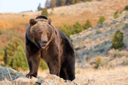

In [9]:
# To load the image from the harddrive to the RAM im = Image.open(dest) is used
# Image comes from a PIL(Python Image Library/Pillow). Fastai uses PIL as its "eyes" to read the images. Here im is now a Python object
#  containing all the pixels of the bear.
im = Image.open(dest)
im.to_thumb(128,128)
# im.to_thumb(128,128) is a very handy fastai extension. Standard PIL images dont have a .to_thumb method but fastai adds it.
# Modern phots are huge (several MBs). If we try to display 50 full-sized images in a notebook, then our browser may crash.
# So, .to_thumb creates a tiny thumbnail version of the image(128x128 pixels) that's lightweight and displayed instantly in our notebook.

Searching for 'black bear'...
This is a: black bear


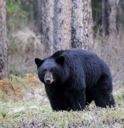

Searching for 'teddy bear'...
This is a: teddy bear


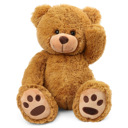

Searching for 'polar bear'...
This is a: polar bear


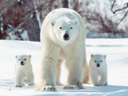

In [10]:
# To display more than one output image in a cell this display() method is used which forces to show the image immediately instead of 
#  waiting for the end of cell. Else in normal way only last line output is overwrittten in display area and only that is displayed.

from IPython.display import display

# Test Searching Multiple Targets

#Define your targets
bear_types = ['black bear', 'teddy bear', 'polar bear']

for bear in bear_types:
    urls = search_images(bear, max_images = 1) # search for the bear
    
    fname = f"{bear.split()[0]}.jpg" # Give each bear its own filename so they dont overwrite each other
    download_url(urls[0], fname, show_progress = False)

    print(f"This is a: {bear}")
    display(Image.open(fname).to_thumb(128,128))

Searching for 'teddy bear'...
Teddy Bear Image #1


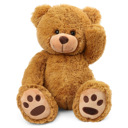

Teddy Bear Image #2


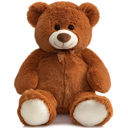

In [11]:
# To display 2 teddy bear images(Test downloading multiple images of one category)

urls = search_images('teddy bear', max_images = 2)

for i in range(2):
    # We name the 2 images as teddy_0.jpg and teddy_1.jpg for them to be unique
    dest = f'teddy_{i}.jpg'
    download_url(urls[i], dest, show_progress = False)

    print(f"Teddy Bear Image #{i+1}")
    display(Image.open(dest).to_thumb(128,128))

In [12]:
# BULK dataset download
bear_types = 'grizzly', 'black', 'teddy', 'polar' # its a tuple
path = Path('bears')
# This is building the dataset structure 
# Using path object here is advantageous here as it automatically handles slashes(/vs\) regardless whether we are on windows, linux, or kaggle.

In [13]:
from time import sleep

In [14]:
#Data Factory cell. Takes the blueprint and designs a real, structured dataset sitting on your Kaggle disk. 
if not path.exists():       # Ensures if folder already present then not to remake it preventing "tripping over itself"
    path.mkdir()            # main folder
    for o in bear_types:
        dest = (path/o)
        dest.mkdir(exist_ok = True)    # exist_ok = True means if subfolder(like grizzly) present then use it instead of crashing
        # Get the URLs
        results = search_images(f'photos of {o} bear', max_images = 150) 
        
        # Download the images
        download_images(dest, urls = results, n_workers = 8)   # n_workers means downloading in parallel 8 images at a time
        sleep(5)
        print(f"Finished downloading {o} bears.")

# for search_images only URLs are downloaded but here in download_images actual images got downloaded and gets saves in "/kaggle/working/" directory.
# sleep(10) will usually add more time searching and make the process more slow

Searching for 'photos of grizzly bear'...
Finished downloading grizzly bears.
Searching for 'photos of black bear'...
Finished downloading black bears.
Searching for 'photos of teddy bear'...
Finished downloading teddy bears.
Searching for 'photos of polar bear'...
Finished downloading polar bears.


In [15]:
# Verify and clean corrupted downloads

# get_image_files looks inside bears folder and all of its subfolders, automatically ignores filetype that aren't images and returns a list
#  of Path objects for every image it finds
fns = get_image_files(path)
fns              # printing this shows a sample of file paths found
print(len(fns))

143


In [16]:
failed = verify_images(fns)
failed
# verify_images opens every file and sees if a file is broken and adds it to a list failed

[Path('bears/grizzly/34aef5e3-e1c0-472f-86e2-e22c2e0c2111.jpg')]

In [17]:
failed.map(Path.unlink)
# "Unlinking" a file basically means deleting it from hard drive
# .map(...): Its a fastcore feature. Instead of writing a for loop, .map says: "Take every single item in the failed list and apply unlink to it"

[None]

In [18]:
# ?verify_images
# ??verify_images
# doc(verify_images)

# ?verify_images 
  # This is the "Quick Help". It opens a small window at the bottom of our screen and ir shows the function signature(what argument it takes) 
  # and the Docstring(the creater's explanation of what it does, here: Find images in 'fns' that can't be opened)
# ??verify_images
  # This does everything that ?verify_images does but along with it it shows the Python code for the function defined itself
# doc(verify_images) #not-working here
  # Its a fastai special function and is a formatted link to the official documentation and examples of how to use it in a project

In [19]:
# Base Datablock Setup
bears = DataBlock(
    blocks = (ImageBlock, CategoryBlock),
    get_items = get_image_files,
    splitter = RandomSplitter(valid_pct = 0.2, seed = 42),
    get_y = parent_label,
    item_tfms = Resize(128))

In [20]:
dls = bears.dataloaders(path)

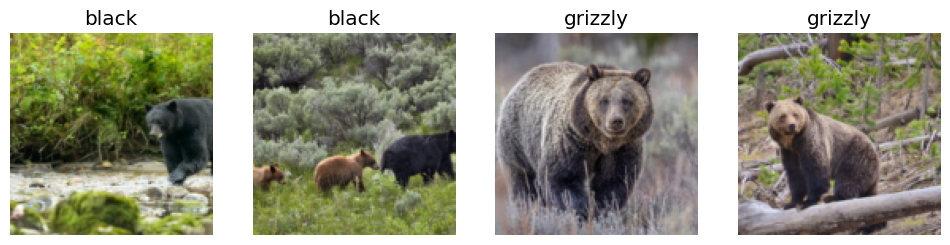

In [21]:
dls.valid.show_batch(max_n = 4, nrows = 1)

#### Experimenting with Resize Strategies

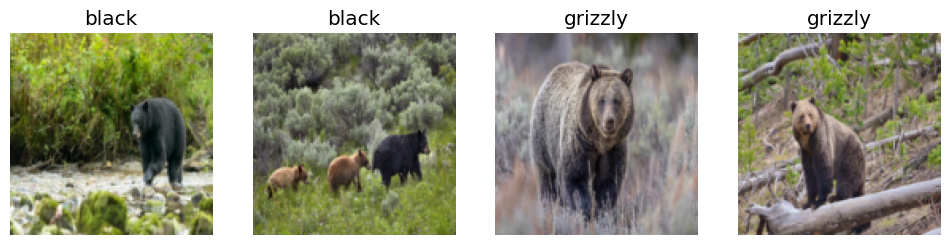

In [22]:
# 1. Squish
bears = bears.new(item_tfms = Resize(128, ResizeMethod.Squish))
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n = 4, nrows = 1)

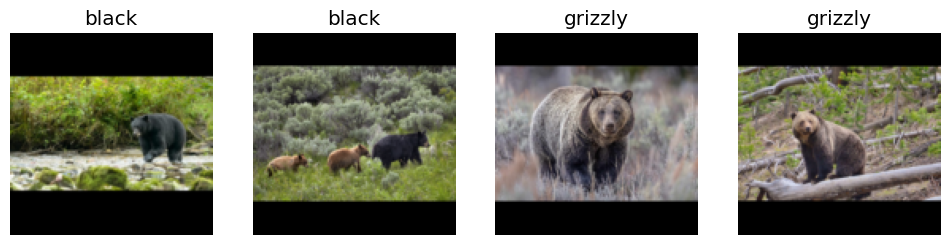

In [23]:
# 2. Pad
bears = bears.new(item_tfms = Resize(128, ResizeMethod.Pad, pad_mode = 'zeros'))
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n = 4, nrows = 1)

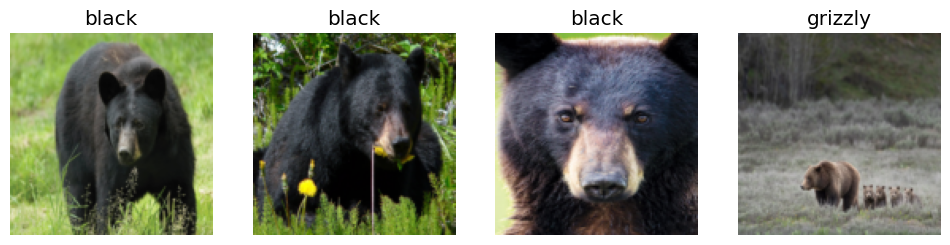

In [24]:
# 3. Random Resized Crop
bears = bears.new(item_tfms = RandomResizedCrop(128, min_scale = 0.3))
dls = bears.dataloaders(path)
# dls.train.show_batch(max_n = 4, nrows = 1, unique = True)
dls.train.show_batch(max_n=4, nrows=1)

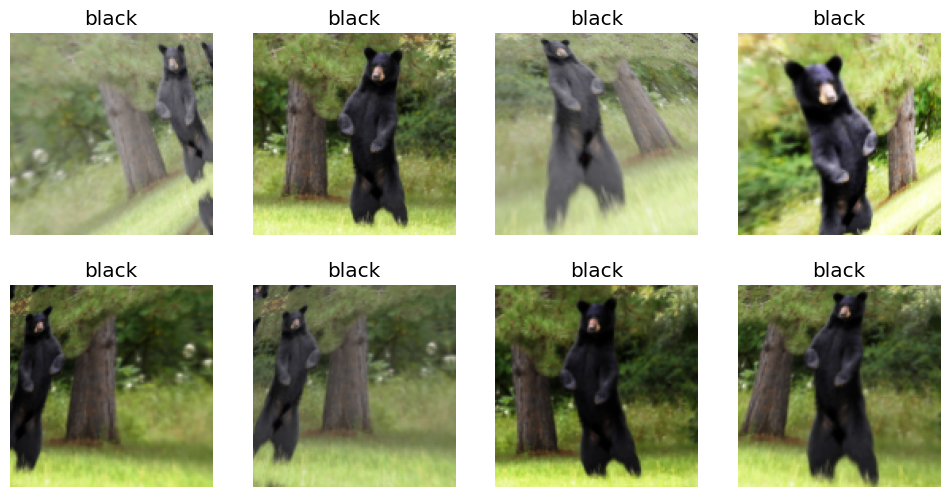

In [25]:
# 4. Data Augmentation(Batch Transforms)
bears = bears.new(item_tfms = Resize(128), batch_tfms = aug_transforms(mult = 2))
dls = bears.dataloaders(path)
dls.train.show_batch(max_n = 8, nrows = 2, unique = True)

In [26]:
# Final DataLoaders and Model Training
bears = bears.new(
    item_tfms = RandomResizedCrop(224, min_scale = 0.5),
    batch_tfms = aug_transforms())
dls = bears.dataloaders(path)

In [27]:
learn = vision_learner(dls, resnet18, metrics = error_rate) #resnet34
learn.fine_tune(4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 133MB/s] 


epoch,train_loss,valid_loss,error_rate,time
0,2.883472,3.198765,0.892857,00:15


epoch,train_loss,valid_loss,error_rate,time
0,2.722216,2.335250,0.714286,00:18
1,2.469171,1.037272,0.285714,00:18
2,1.874920,0.586017,0.178571,00:18
3,1.552718,0.412256,0.178571,00:19


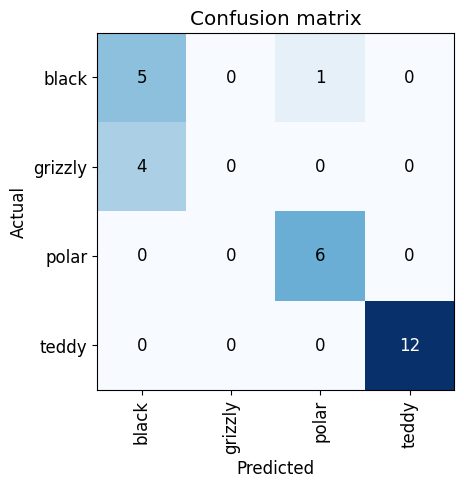

In [28]:
# Model Interpretation
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

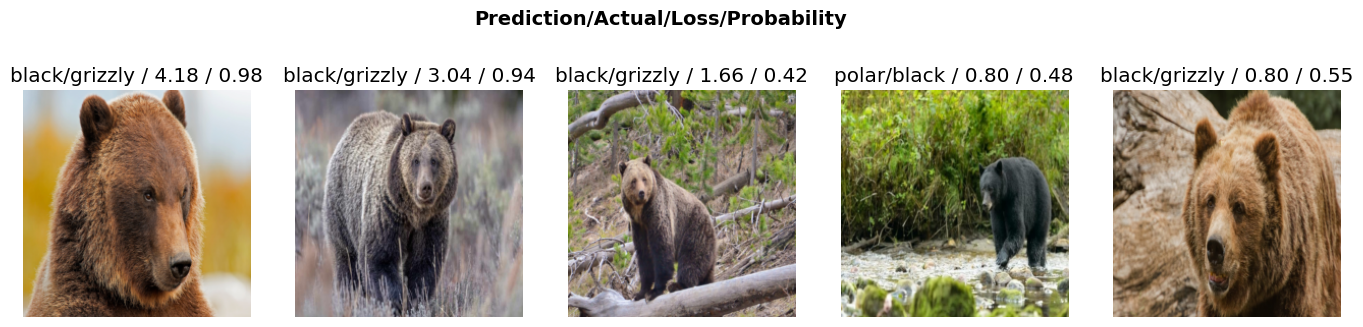

In [29]:
interp.plot_top_losses(5, nrows = 1, figsize = (17,4))

In [40]:
# # Interactive Data Cleaner
# cleaner = ImageClassifierCleaner(learn)
# cleaner

In [31]:
# cleanup mislabeled / corrupted data
for idx in cleaner.delete(): 
    cleaner.fns[idx].unlink() # delete bad images from the disk
    
for idx, cat in cleaner.change(): 
    shutil.move(str(cleaner.fns[idx]), path/cat) #move mislabeled imaged to the correct folder

### Retrain after Cleanup

In [32]:
# Re-create DataLoaders with the cleaned dataset and fine-tune again
dls = bears.dataloaders(path)
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(4)

epoch,train_loss,valid_loss,error_rate,time
0,2.779654,3.225806,0.892857,00:15


epoch,train_loss,valid_loss,error_rate,time
0,2.499129,2.429919,0.678571,00:18
1,2.361171,0.977838,0.357143,00:19
2,1.831660,0.459525,0.214286,00:18
3,1.464693,0.298785,0.178571,00:18


In [34]:
learn.export('bear_classifier.pkl')

In [35]:
# LOAD MODEL & INFERENCE ON A NEW IMAGE

# Load the exported learner
learn_inf = load_learner('bear_classifier.pkl')

# Test single image prediction
# Using one of our downlaoded test images (e.g., 'teddy_0.jpg')
pred, pred_idx, probs = learn_inf.predict('teddy_0.jpg')

print(f"Prediction: {pred}")
print(f"Probability: {probs[pred_idx]:.04f}")

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:456: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


Prediction: teddy
Probability: 0.9994
